In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [5]:
print(sentiment.shape)
print(trades.shape)

print(sentiment.info())
print(trades.info())

print(sentiment.isnull().sum())
print(trades.isnull().sum())

print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

(2644, 4)
(211224, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  

In [7]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [8]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

In [10]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['timestamp'] = pd.to_datetime(trades['timestamp'])

In [11]:
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['timestamp'].dt.date

In [12]:
merged = pd.merge(trades, sentiment, on='date', how='left')

In [13]:
print(merged.head())

                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side     timestamp ist  start position direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   closed pnl                                   transaction hash     order id  \
0         0.0  0xec0945

In [32]:
print(trades.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'date'],
      dtype='str')


In [33]:
daily_pnl = merged.groupby(['account', 'date'])['closed pnl'].sum().reset_index()

In [30]:
merged['win'] = merged['closed pnl'] > 0
win_rate = merged.groupby('account')['win'].mean()

In [34]:
avg_trade_size = merged.groupby('account')['size tokens'].mean()

In [35]:
avg_trade_size = merged.groupby('account')['size usd'].mean()

In [37]:
merged['size usd']

0         7872.16
1          127.68
2         1150.63
3         1142.04
4           69.75
           ...   
211219     420.80
211220    2338.63
211221     466.16
211222    3963.38
211223    1119.83
Name: size usd, Length: 211224, dtype: float64

In [38]:
merged['closed pnl']

0           0.0000
1           0.0000
2           0.0000
3           0.0000
4           0.0000
            ...   
211219    -20.2566
211220   -112.5773
211221    -22.4402
211222   -190.7894
211223    -53.9063
Name: closed pnl, Length: 211224, dtype: float64

In [39]:
merged['side']

0          BUY
1          BUY
2          BUY
3          BUY
4          BUY
          ... 
211219    SELL
211220    SELL
211221    SELL
211222    SELL
211223    SELL
Name: side, Length: 211224, dtype: str

In [40]:
merged.groupby('classification')['size usd'].mean()

Series([], Name: size usd, dtype: float64)

In [41]:
merged.groupby(['classification','size usd']).size()

Series([], dtype: int64)

In [43]:
merged['size type'] = merged['size usd'].apply(lambda x: 'High' if x > 1000 else 'Low')

In [45]:
trades_per_day = merged.groupby('date').size()

In [46]:
long_short = merged['side'].value_counts(normalize=True)

In [49]:
merged.groupby('classification')['closed pnl'].mean()

Series([], Name: closed pnl, dtype: float64)

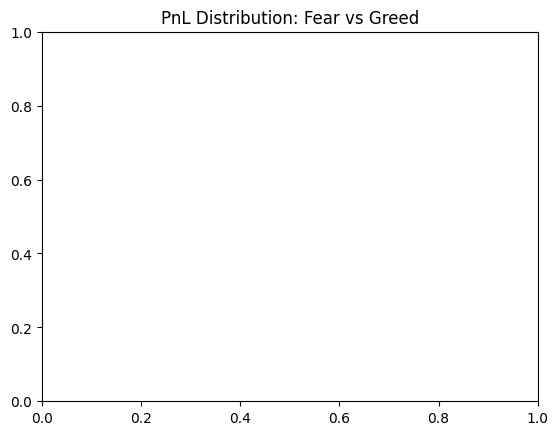

In [51]:
merged = merged.dropna(subset=['classification', 'closed pnl'])

sns.boxplot(x='classification', y='closed pnl', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

In [52]:
print(merged['classification'].unique())

<StringArray>
[]
Length: 0, dtype: str


In [53]:
print(merged.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification', 'win',
       'size type'],
      dtype='str')


In [56]:
merged.groupby('classification')['closed pnl'].mean()
merged.groupby('classification')['size usd'].mean()

Series([], Name: size usd, dtype: float64)

In [57]:
merged['size type'] = np.where(merged['size usd'] > merged['size usd'].median(), 'High', 'Low')

In [58]:
trade_counts = merged['account'].value_counts()

merged['trader_type'] = merged['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent'
)

In [59]:
profit = merged.groupby('account')['closed pnl'].sum()

merged['profit_type'] = merged['account'].map(
    lambda x: 'Winner' if profit[x] > 0 else 'Loser'
)

In [61]:
merged.groupby('size type')['closed pnl'].mean()
merged.groupby('trader_type')['closed pnl'].mean()
merged.groupby('profit_type')['closed pnl'].mean()

Series([], Name: closed pnl, dtype: float64)

In [67]:
!pip install scikit-learn

In [65]:
!python -m pip install --upgrade pip

     ---------------------------------------- 1.8/1.8 MB 646.4 kB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 22.3.1
    Uninstalling pip-22.3.1:
      Successfully uninstalled pip-22.3.1


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [69]:
print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side     timestamp ist  start position direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [70]:
print(merged.groupby('classification')['closed pnl'].mean())

Series([], Name: closed pnl, dtype: float64)


In [71]:
plt.show()

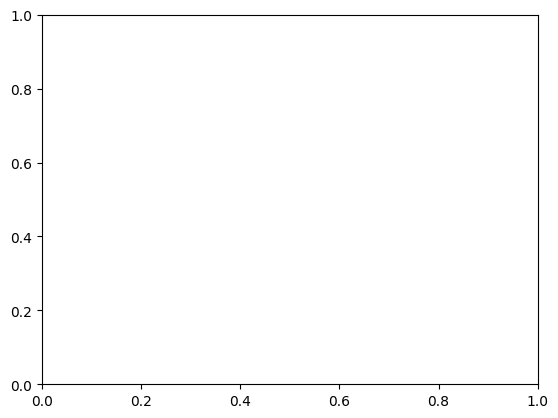

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed pnl', data=merged)
plt.show()

In [74]:
print(merged.shape)

(0, 24)


In [75]:
print(merged.head())

Empty DataFrame
Columns: [account, coin, execution price, size tokens, size usd, side, timestamp ist, start position, direction, closed pnl, transaction hash, order id, crossed, fee, trade id, timestamp_x, date, timestamp_y, value, classification, win, size type, trader_type, profit_type]
Index: []

[0 rows x 24 columns]


In [76]:
print(trades['date'].head())
print(sentiment['date'].head())

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
Name: date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [79]:
print("Merged shape:", merged.shape)
print(merged.head())

print("Columns:", merged.columns)

Merged shape: (0, 24)
Empty DataFrame
Columns: [account, coin, execution price, size tokens, size usd, side, timestamp ist, start position, direction, closed pnl, transaction hash, order id, crossed, fee, trade id, timestamp_x, date, timestamp_y, value, classification, win, size type, trader_type, profit_type]
Index: []

[0 rows x 24 columns]
Columns: Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification', 'win',
       'size type', 'trader_type', 'profit_type'],
      dtype='str')


In [80]:
%matplotlib inline

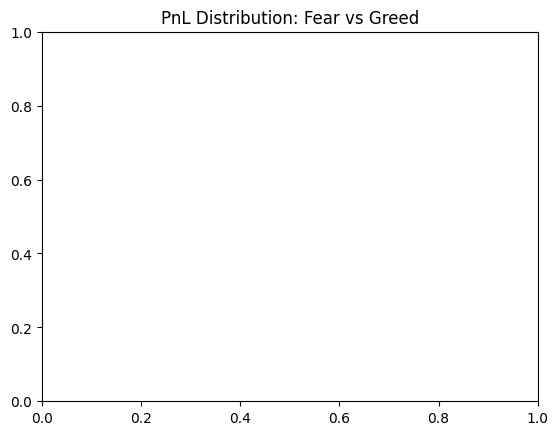

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed pnl', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

In [83]:
print(merged.shape)

(0, 24)


In [84]:
print(merged.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification', 'win',
       'size type', 'trader_type', 'profit_type'],
      dtype='str')


In [85]:
merged = merged.dropna(subset=['classification', 'closed pnl'])

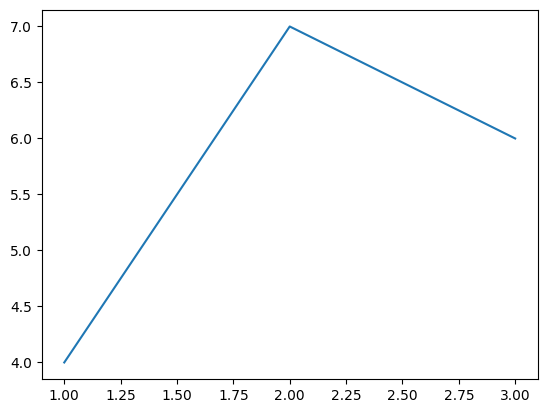

In [88]:
plt.plot([1,2,3], [4,7,6])
plt.show()

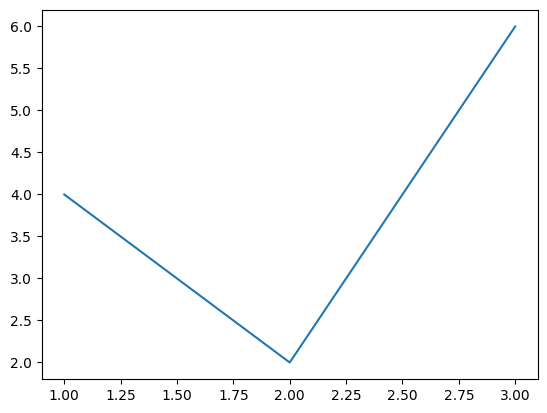

In [89]:
plt.plot([1,2,3], [4,2,6])
plt.show()

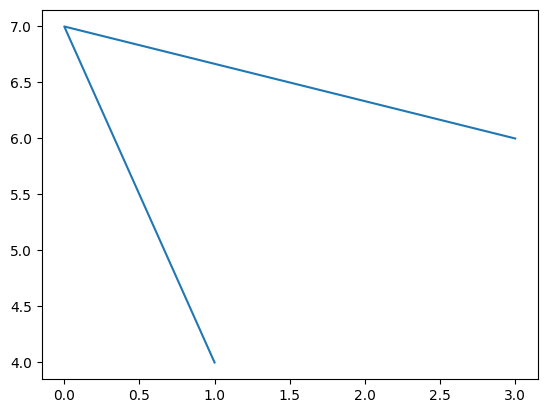

In [90]:
plt.plot([1,0,3], [4,7,6])
plt.show()

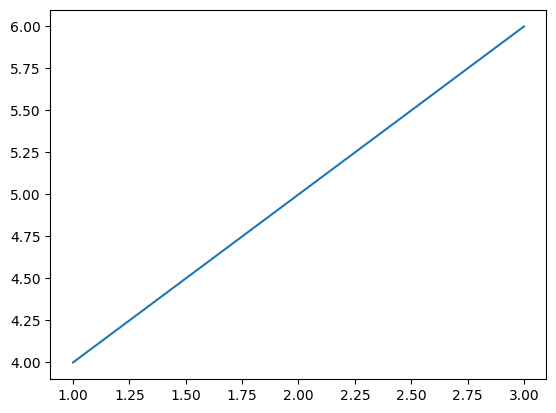

In [91]:
plt.plot([1,2,3], [4,5,6])
plt.show()

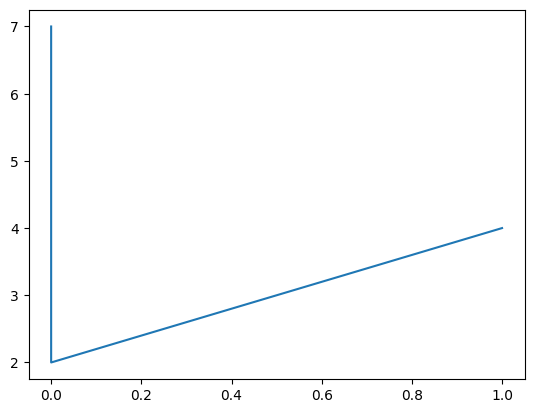

In [92]:
plt.plot([1,0,0], [4,2,7])
plt.show()